# 1. Data Inventory & Setup

In [1]:
import pandas
import matplotlib.pyplot
import pathlib

RAW_DATA_PATH = pathlib.Path("data/raw")
csv_files = sorted(list(RAW_DATA_PATH.glob("*.csv")))

inventory_data = []

# 1. Loop through files to get counts for the table
for file_path in csv_files:
    df = pandas.read_csv(file_path, low_memory=False)

    inventory_data.append(
        {
            "file": file_path.name,
            "size_mb": round(file_path.stat().st_size / (1024 * 1024), 2),
            "rows": len(df),
            "cols": len(df.columns),
        }
    )

inventory_df = pandas.DataFrame(inventory_data)

# 2. Print table to verify all years loaded
print("SJPD Dataset Audit:")
display(inventory_df.style.format({"rows": "{:,}"}))
# 3. Print summary statistics
total_rows = inventory_df['rows'].sum()
print(f"\nTotal records analyzed: {total_rows:,}")

SJPD Dataset Audit:


,file,size_mb,rows,cols
0,policecalls2016.csv,67.310000,"309,252",15
1,policecalls2017.csv,68.820000,"316,174",15
2,policecalls2018.csv,70.480000,"322,365",15
3,policecalls2019.csv,70.640000,"322,624",15
4,policecalls2020.csv,65.110000,"297,458",15
5,policecalls2021.csv,67.280000,"302,119",15
6,policecalls2022.csv,66.160000,"294,515",15
7,policecalls2023.csv,64.130000,"286,481",15
8,policecalls2024.csv,43.590000,"272,506",16
9,policecalls2025.csv,48.460000,"262,095",16



Total records analyzed: 3,077,538


# 2. Annual Call Trends

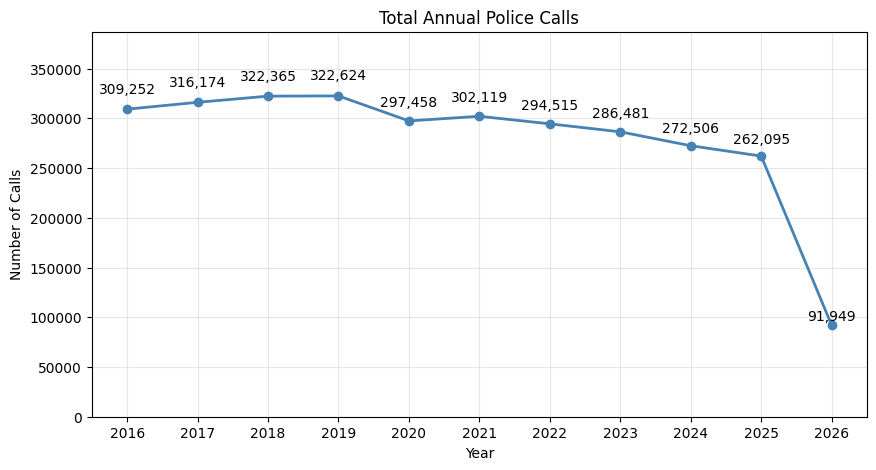

In [2]:
# 1. Get the year from the filename for the X-axis
inventory_df["year"] = inventory_df["file"].str.extract(r"(\d{4})")

matplotlib.pyplot.figure(figsize=(10, 5))
matplotlib.pyplot.plot(
    inventory_df["year"],
    inventory_df["rows"],
    marker="o",
    color="steelblue",
    linewidth=2,
)

for i in range(len(inventory_df)):
    matplotlib.pyplot.text(i, inventory_df.rows[i] * 1.05, f"{inventory_df.rows[i]:,}", ha="center")

# 2. Plot the annual trend of police calls
matplotlib.pyplot.title("Total Annual Police Calls")
matplotlib.pyplot.xlabel("Year")
matplotlib.pyplot.ylabel("Number of Calls")
matplotlib.pyplot.ylim(0, inventory_df.rows.max() * 1.2)
matplotlib.pyplot.grid(True, alpha=0.3)
matplotlib.pyplot.show()

# 3. Daily Volume & Surges

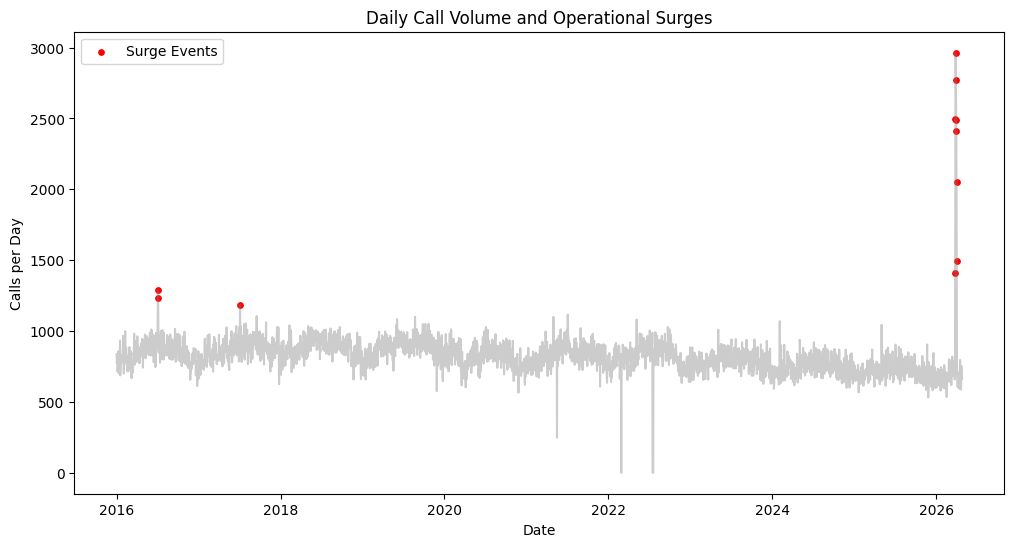

In [3]:
all_dfs = []

for file_path in csv_files:
    df = pandas.read_csv(file_path, low_memory=False)
    df["OFFENSE_DATE"] = pandas.to_datetime(df["OFFENSE_DATE"], format="mixed")
    all_dfs.append(df[["OFFENSE_DATE"]])

master_df = pandas.concat(all_dfs)

# 1. Group calls by day to see the volume
daily_counts = master_df.set_index("OFFENSE_DATE").resample("D").size()

matplotlib.pyplot.figure(figsize=(12, 6))
matplotlib.pyplot.plot(daily_counts.index, daily_counts.values, color="gray", alpha=0.4)

# 2. Mark extreme spikes as red outliers (3 std dev)
threshold = daily_counts.mean() + (3 * daily_counts.std())
surges = daily_counts[daily_counts > threshold]

matplotlib.pyplot.scatter(surges.index, surges.values, color="red", s=15, label="Surge Events")

matplotlib.pyplot.title("Daily Call Volume and Operational Surges")
matplotlib.pyplot.xlabel("Date")
matplotlib.pyplot.ylabel("Calls per Day")
matplotlib.pyplot.legend()
matplotlib.pyplot.show()